# Practica 2 - Ejercicio 6: Consumo de autos

**Enunciado:** Dataset `auto.xlsx` con 392 autos. Calcular % Ford, visualizar distribucion por
origen, ajustar regresion mpg ~ horsepower, e identificar posibles mejoras al modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_excel("../Datasets/Parte_2/auto.xlsx")
# Limpiar horsepower (puede contener '?')
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["mpg", "horsepower"])
print(f"Filas validas: {len(df)}")
print(df.head())
print(df[["mpg", "horsepower"]].describe())

Filas validas: 392
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
              mpg  horsepower
count  392.000000  392.000000
mean    23.445918  104.469388
std      7.805007   38.491160
min      9.000000   46.000000
25%     17.000000   75.000000
50%     22.750000   93.500000
75%     29.000000  126.000000
max     46.600000  230.000000


## 1. Porcentaje de autos Ford

In [3]:
n_ford   = df["name"].str.lower().str.contains("ford").sum()
pct_ford = n_ford / len(df) * 100
print(f"Autos Ford: {n_ford} de {len(df)} -> {pct_ford:.2f}%")

Autos Ford: 48 de 392 -> 12.24%


## 2. Distribucion por origen

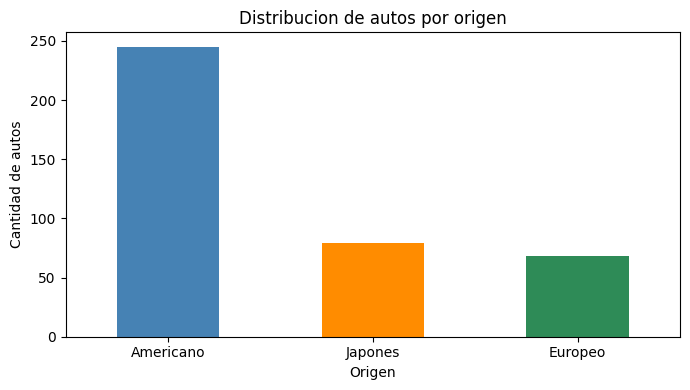

In [4]:
origin_map = {1: "Americano", 2: "Europeo", 3: "Japones"}
df["origin_label"] = df["origin"].map(origin_map)

fig, ax = plt.subplots(figsize=(7, 4))
df["origin_label"].value_counts().plot(kind="bar", ax=ax,
                                        color=["steelblue", "darkorange", "seagreen"])
ax.set_xlabel("Origen")
ax.set_ylabel("Cantidad de autos")
ax.set_title("Distribucion de autos por origen")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Regresion simple: mpg ~ horsepower

In [5]:
mod = smf.ols("mpg ~ horsepower", data=df)
res = mod.fit()
print(res.summary())

b0 = res.params["Intercept"]
b1 = res.params["horsepower"]
print(f"\nModelo: mpg = {b0:.4f} + ({b1:.4f}) * horsepower")
print(f"Relacion: {'negativa' if b1 < 0 else 'positiva'}")
print(f"R2 = {res.rsquared:.4f} ({res.rsquared*100:.1f}% de la variabilidad explicada)")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           7.03e-81
Time:                        18:01:37   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

## 4. Visualizacion del ajuste

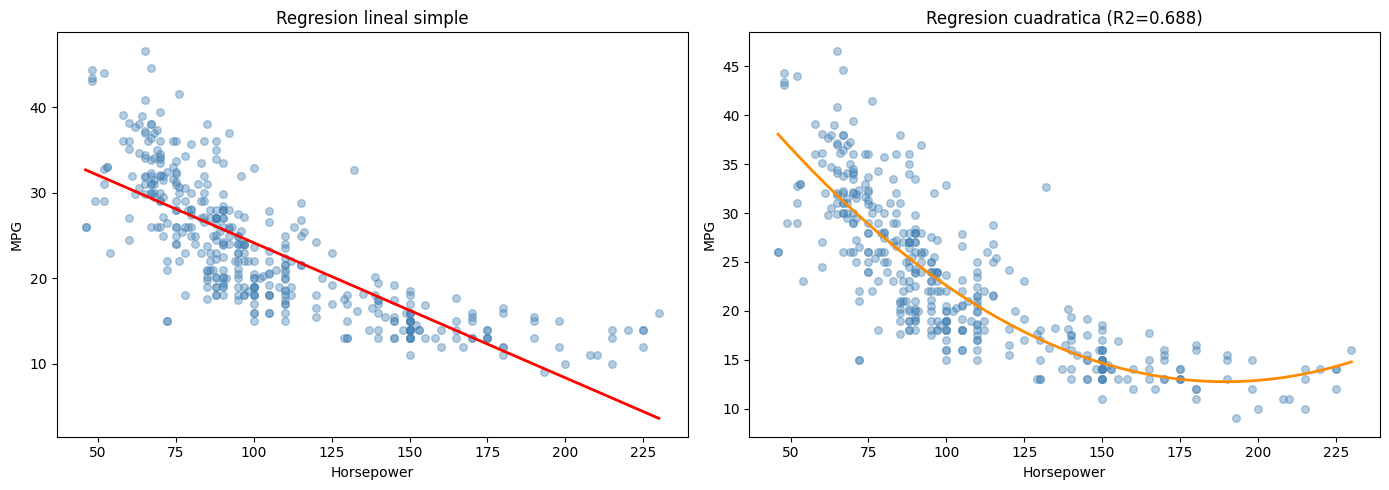

Modelo cuadratico: R2 = 0.6876


In [6]:
hp_seq = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["horsepower"], df["mpg"], color="steelblue", alpha=0.4, s=30)
axes[0].plot(hp_seq, res.predict(pd.DataFrame({"horsepower": hp_seq})), color="red", lw=2)
axes[0].set_xlabel("Horsepower")
axes[0].set_ylabel("MPG")
axes[0].set_title("Regresion lineal simple")

# Modelo cuadratico
mod2 = smf.ols("mpg ~ horsepower + I(horsepower**2)", data=df)
res2 = mod2.fit()
pred_quad = res2.predict(pd.DataFrame({"horsepower": hp_seq}))

axes[1].scatter(df["horsepower"], df["mpg"], color="steelblue", alpha=0.4, s=30)
axes[1].plot(hp_seq, pred_quad, color="darkorange", lw=2)
axes[1].set_xlabel("Horsepower")
axes[1].set_ylabel("MPG")
axes[1].set_title(f"Regresion cuadratica (R2={res2.rsquared:.3f})")
plt.tight_layout()
plt.show()

print(f"Modelo cuadratico: R2 = {res2.rsquared:.4f}")

## Conclusiones

**3a. Signo de la relacion:** La relacion es **negativa** (β₁ = -0.1578). A mayor potencia del
motor, menor es el consumo en millas por galon.

**3b. Interpretacion del coeficiente:** Por cada caballo de fuerza adicional, el rendimiento
del combustible disminuye en promedio 0.1578 millas por galon.

**3c. R² = 0.606:** El modelo de regresion lineal simple explica el 60.6% de la variabilidad
en el consumo de los vehiculos.

**3d. Limitacion del modelo:** El grafico muestra que la relacion entre mpg y horsepower
no es estrictamente lineal: la nube de puntos sigue una curva mas pronunciada en valores bajos
de horsepower y se aplana en valores altos. La recta de regresion no captura este comportamiento.

**Mejora propuesta:** Un modelo polinomico de grado 2 mejora el ajuste (R² = 0.688) al
incorporar el termino I(horsepower**2), capturando la curvatura de la relacion.